# Lab 3: Descriptive Statistical Techniques
## Objective
Apply descriptive statistical techniques to summarize and interpret datasets.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')
feature_cols = df.columns[:-1]
class_names = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}

print(f"Shape: {df.shape}")
df.head()

Shape: (210, 8)


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


## 3. Measures of Central Tendency

In [3]:
print("=" * 60)
print("MEASURES OF CENTRAL TENDENCY")
print("=" * 60)

central_tendency = pd.DataFrame({
    'Mean': df[feature_cols].mean(),
    'Median': df[feature_cols].median(),
    'Mode': df[feature_cols].mode().iloc[0]
})

central_tendency

MEASURES OF CENTRAL TENDENCY


,Mean,Median,Mode
Area,14.847524,14.35500,11.2300
Perimeter,14.559286,14.32000,13.4700
Compactness,0.870999,0.87345,0.8823
Length_of_kernel,5.628533,5.52350,5.2360
Width_of_kernel,3.258605,3.23700,3.0260
Asymmetry_coefficient,3.700201,3.59900,2.1290
Length_of_kernel_groove,5.408071,5.22300,5.0010


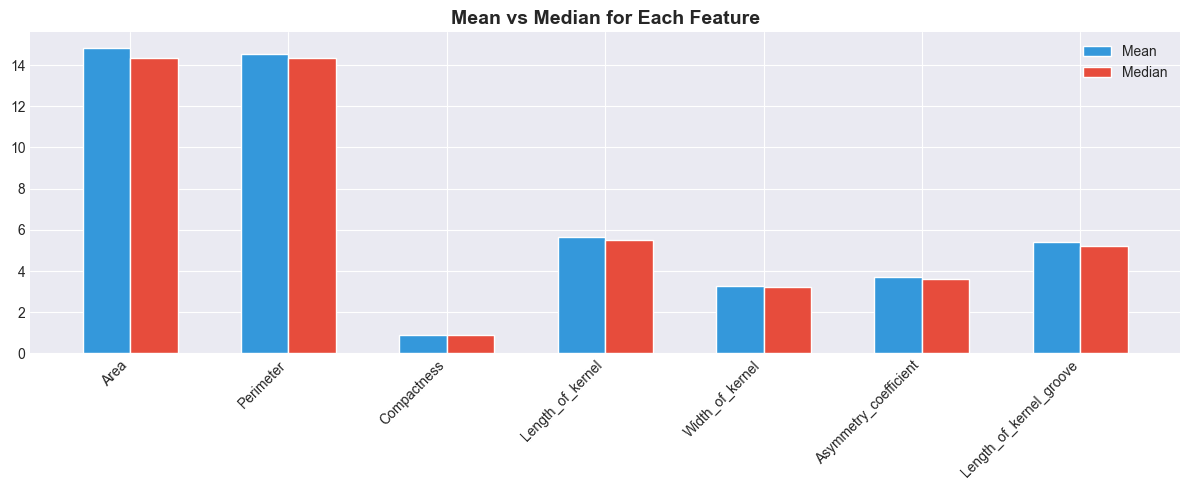

In [4]:
# Visualize mean vs median
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(feature_cols))
width = 0.3

ax.bar(x - width/2, central_tendency['Mean'], width, label='Mean', color='#3498db', edgecolor='white')
ax.bar(x + width/2, central_tendency['Median'], width, label='Median', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_title('Mean vs Median for Each Feature', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Measures of Dispersion

In [5]:
print("=" * 60)
print("MEASURES OF DISPERSION")
print("=" * 60)

dispersion = pd.DataFrame({
    'Std Dev': df[feature_cols].std(),
    'Variance': df[feature_cols].var(),
    'Range': df[feature_cols].max() - df[feature_cols].min(),
    'IQR': df[feature_cols].quantile(0.75) - df[feature_cols].quantile(0.25),
    'Coeff of Variation (%)': (df[feature_cols].std() / df[feature_cols].mean() * 100)
})

dispersion.round(4)

MEASURES OF DISPERSION


,Std Dev,Variance,Range,IQR,Coeff of Variation (%)
Area,2.9097,8.4664,10.5900,5.0350,19.5972
Perimeter,1.3060,1.7055,4.8400,2.2650,8.9699
Compactness,0.0236,0.0006,0.1102,0.0309,2.7129
Length_of_kernel,0.4431,0.1963,1.7760,0.7175,7.8717
Width_of_kernel,0.3777,0.1427,1.4030,0.6178,11.5913
Asymmetry_coefficient,1.5036,2.2607,7.6909,2.2072,40.6345
Length_of_kernel_groove,0.4915,0.2416,2.0310,0.8320,9.0879


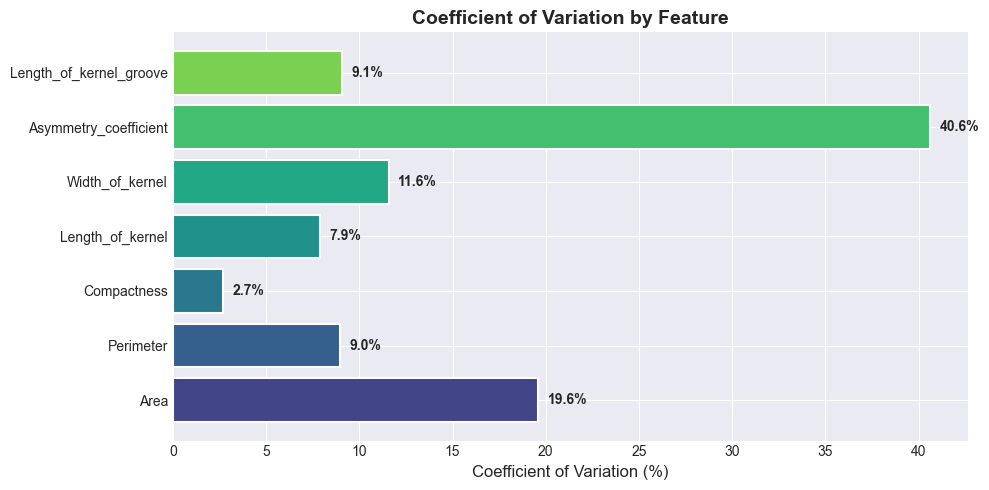

In [6]:
# Coefficient of Variation comparison
fig, ax = plt.subplots(figsize=(10, 5))
cv = dispersion['Coeff of Variation (%)']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(cv)))
bars = ax.barh(cv.index, cv.values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Coefficient of Variation (%)', fontsize=12)
ax.set_title('Coefficient of Variation by Feature', fontsize=14, fontweight='bold')

for bar, val in zip(bars, cv.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Measures of Shape (Skewness & Kurtosis)

In [7]:
print("=" * 60)
print("MEASURES OF SHAPE")
print("=" * 60)

shape_measures = pd.DataFrame({
    'Skewness': df[feature_cols].skew(),
    'Kurtosis': df[feature_cols].kurtosis(),
    'Skew Interpretation': df[feature_cols].skew().apply(
        lambda x: 'Right-skewed' if x > 0.5 else ('Left-skewed' if x < -0.5 else 'Approx. Symmetric')
    ),
    'Kurtosis Interpretation': df[feature_cols].kurtosis().apply(
        lambda x: 'Leptokurtic (heavy tails)' if x > 0 else 'Platykurtic (light tails)'
    )
})

shape_measures

MEASURES OF SHAPE


,Skewness,Kurtosis,Skew Interpretation,Kurtosis Interpretation
Area,0.399889,-1.084266,Approx. Symmetric,Platykurtic (light tails)
Perimeter,0.386573,-1.106703,Approx. Symmetric,Platykurtic (light tails)
Compactness,-0.537954,-0.140315,Left-skewed,Platykurtic (light tails)
Length_of_kernel,0.525482,-0.785645,Right-skewed,Platykurtic (light tails)
Width_of_kernel,0.134378,-1.097697,Approx. Symmetric,Platykurtic (light tails)
Asymmetry_coefficient,0.401667,-0.066603,Approx. Symmetric,Platykurtic (light tails)
Length_of_kernel_groove,0.561897,-0.840792,Right-skewed,Platykurtic (light tails)


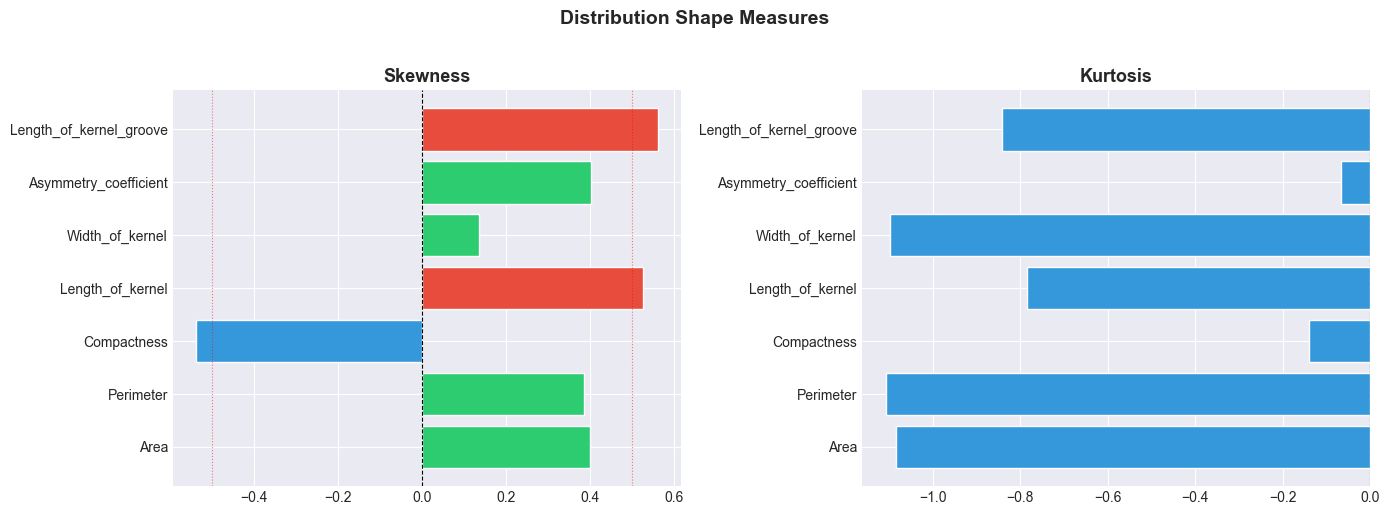

In [8]:
# Visualize skewness and kurtosis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skewness
skew_vals = shape_measures['Skewness']
colors_skew = ['#e74c3c' if v > 0.5 else '#3498db' if v < -0.5 else '#2ecc71' for v in skew_vals]
axes[0].barh(skew_vals.index, skew_vals.values, color=colors_skew, edgecolor='white')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(x=0.5, color='red', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].axvline(x=-0.5, color='red', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].set_title('Skewness', fontsize=13, fontweight='bold')

# Kurtosis
kurt_vals = shape_measures['Kurtosis']
colors_kurt = ['#e74c3c' if v > 0 else '#3498db' for v in kurt_vals]
axes[1].barh(kurt_vals.index, kurt_vals.values, color=colors_kurt, edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Kurtosis', fontsize=13, fontweight='bold')

plt.suptitle('Distribution Shape Measures', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Percentiles and Quartiles

In [9]:
print("=" * 60)
print("PERCENTILES AND QUARTILES")
print("=" * 60)

percentiles = df[feature_cols].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
percentiles.index = ['10th', '25th (Q1)', '50th (Q2/Median)', '75th (Q3)', '90th']
percentiles.round(4)

PERCENTILES AND QUARTILES


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
10th,11.333,13.019,0.8375,5.1307,2.7625,1.7886,4.8699
25th (Q1),12.270,13.450,0.8569,5.2622,2.9440,2.5615,5.0450
50th (Q2/Median),14.355,14.320,0.8734,5.5235,3.2370,3.5990,5.2230
75th (Q3),17.305,15.715,0.8878,5.9798,3.5618,4.7688,5.8770
90th,18.988,16.454,0.8993,6.2733,3.7865,5.5376,6.1850


## 7. Class-wise Descriptive Statistics

In [10]:
print("=" * 60)
print("CLASS-WISE STATISTICS")
print("=" * 60)

for cls in sorted(df['Class'].unique()):
    print(f"\n--- {class_names[cls]} (Class {cls}) ---")
    print(df[df['Class'] == cls][feature_cols].describe().round(4))
    print()

CLASS-WISE STATISTICS

--- Kama (Class 1) ---
          Area  Perimeter  Compactness  Length_of_kernel  Width_of_kernel  \
count  70.0000    70.0000      70.0000           70.0000          70.0000   
mean   14.3344    14.2943       0.8801            5.5081           3.2446   
std     1.2157     0.5766       0.0162            0.2315           0.1776   
min    11.2300    12.6300       0.8392            4.9020           2.8500   
25%    13.7500    13.9600       0.8688            5.3845           3.1342   
50%    14.3550    14.3200       0.8805            5.5340           3.2435   
75%    15.0450    14.7325       0.8904            5.6770           3.3785   
max    17.0800    15.4600       0.9183            6.0530           3.6830   

       Asymmetry_coefficient  Length_of_kernel_groove  
count                70.0000                  70.0000  
mean                  2.6674                   5.0872  
std                   1.1739                   0.2637  
min                   0.7651        

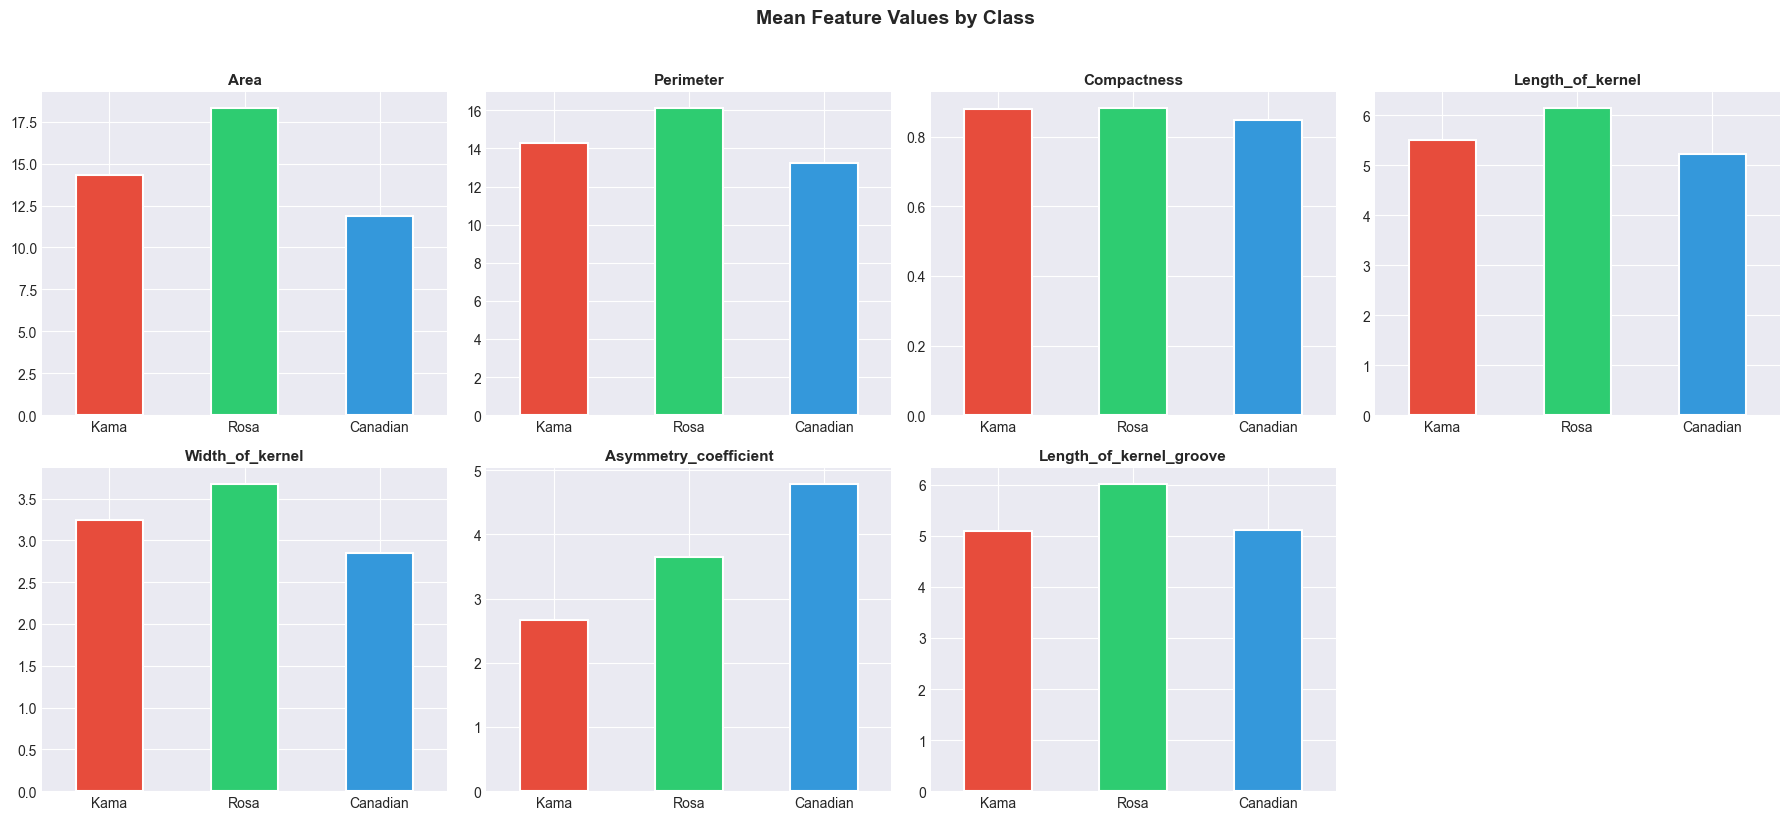

In [11]:
# Class-wise mean comparison
class_means = df.groupby('Class')[feature_cols].mean()
class_means.index = [class_names[c] for c in class_means.index]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    class_means[col].plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71', '#3498db'],
                          edgecolor='white', linewidth=1.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

axes[-1].set_visible(False)
plt.suptitle('Mean Feature Values by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

PEARSON CORRELATION MATRIX


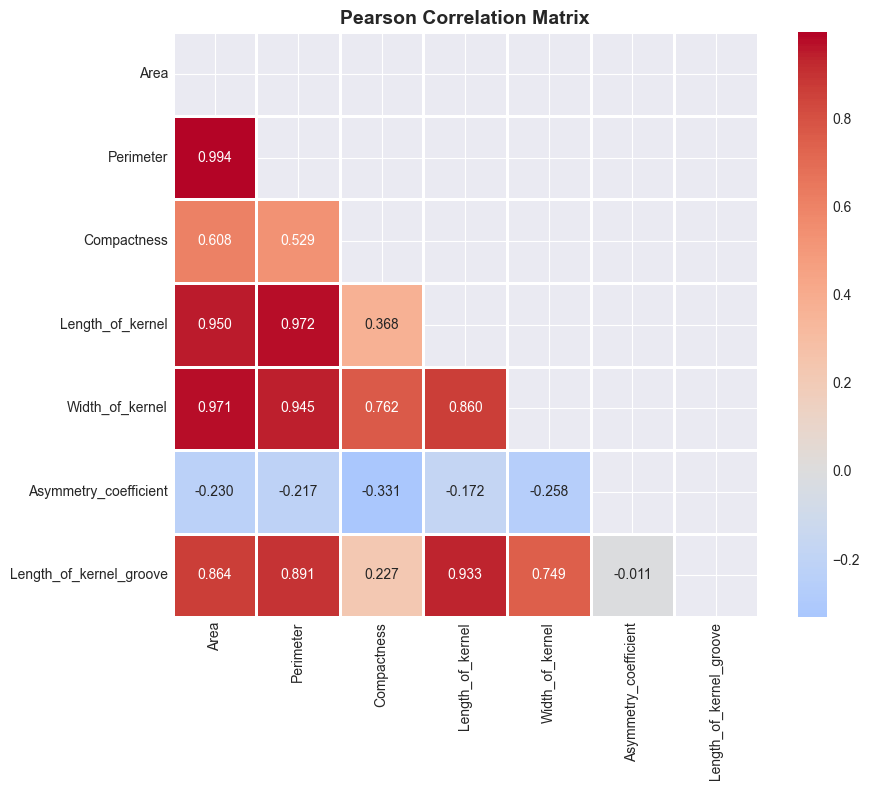

In [12]:
# Pearson correlation
print("=" * 60)
print("PEARSON CORRELATION MATRIX")
print("=" * 60)

corr_matrix = df[feature_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Find strongly correlated features
print("\nStrongly Correlated Feature Pairs (|r| > 0.7):")
print("=" * 55)

for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {feature_cols[i]:25s} vs {feature_cols[j]:25s}: r = {corr_val:.4f}")


Strongly Correlated Feature Pairs (|r| > 0.7):
  Area                      vs Perimeter                : r = 0.9943
  Area                      vs Length_of_kernel         : r = 0.9500
  Area                      vs Width_of_kernel          : r = 0.9708
  Area                      vs Length_of_kernel_groove  : r = 0.8637
  Perimeter                 vs Length_of_kernel         : r = 0.9724
  Perimeter                 vs Width_of_kernel          : r = 0.9448
  Perimeter                 vs Length_of_kernel_groove  : r = 0.8908
  Compactness               vs Width_of_kernel          : r = 0.7616
  Length_of_kernel          vs Width_of_kernel          : r = 0.8604
  Length_of_kernel          vs Length_of_kernel_groove  : r = 0.9328
  Width_of_kernel           vs Length_of_kernel_groove  : r = 0.7491


## 9. Hypothesis Testing

In [14]:
# Shapiro-Wilk test for normality
print("=" * 60)
print("SHAPIRO-WILK NORMALITY TEST (α = 0.05)")
print("=" * 60)

for col in feature_cols:
    stat, p_value = stats.shapiro(df[col])
    result = '✅ Normal' if p_value > 0.05 else '❌ Not Normal'
    print(f"{col:30s}: W = {stat:.4f}, p = {p_value:.6f} → {result}")

SHAPIRO-WILK NORMALITY TEST (α = 0.05)
Area                          : W = 0.9326, p = 0.000000 → ❌ Not Normal
Perimeter                     : W = 0.9362, p = 0.000000 → ❌ Not Normal
Compactness                   : W = 0.9730, p = 0.000470 → ❌ Not Normal
Length_of_kernel              : W = 0.9438, p = 0.000000 → ❌ Not Normal
Width_of_kernel               : W = 0.9606, p = 0.000014 → ❌ Not Normal
Asymmetry_coefficient         : W = 0.9836, p = 0.015439 → ❌ Not Normal
Length_of_kernel_groove       : W = 0.9249, p = 0.000000 → ❌ Not Normal


In [15]:
# One-Way ANOVA: Test if feature means differ across classes
print("\n" + "=" * 60)
print("ONE-WAY ANOVA TEST (α = 0.05)")
print("H0: Mean values are equal across all wheat varieties")
print("=" * 60)

for col in feature_cols:
    groups = [df[df['Class'] == cls][col].values for cls in sorted(df['Class'].unique())]
    f_stat, p_value = stats.f_oneway(*groups)
    result = '✅ Significant difference' if p_value < 0.05 else '❌ No significant difference'
    print(f"{col:30s}: F = {f_stat:8.4f}, p = {p_value:.6f} → {result}")


ONE-WAY ANOVA TEST (α = 0.05)
H0: Mean values are equal across all wheat varieties
Area                          : F = 548.1865, p = 0.000000 → ✅ Significant difference
Perimeter                     : F = 541.5795, p = 0.000000 → ✅ Significant difference
Compactness                   : F =  75.8690, p = 0.000000 → ✅ Significant difference
Length_of_kernel              : F = 322.1859, p = 0.000000 → ✅ Significant difference
Width_of_kernel               : F = 406.3020, p = 0.000000 → ✅ Significant difference
Asymmetry_coefficient         : F =  51.8881, p = 0.000000 → ✅ Significant difference
Length_of_kernel_groove       : F = 368.9500, p = 0.000000 → ✅ Significant difference


## 10. Summary Statistics Table

In [16]:
summary = pd.DataFrame({
    'Mean': df[feature_cols].mean(),
    'Median': df[feature_cols].median(),
    'Std Dev': df[feature_cols].std(),
    'Min': df[feature_cols].min(),
    'Max': df[feature_cols].max(),
    'Range': df[feature_cols].max() - df[feature_cols].min(),
    'IQR': df[feature_cols].quantile(0.75) - df[feature_cols].quantile(0.25),
    'Skewness': df[feature_cols].skew(),
    'Kurtosis': df[feature_cols].kurtosis(),
    'CV (%)': (df[feature_cols].std() / df[feature_cols].mean() * 100)
})

print("\nComprehensive Summary Statistics:")
summary.round(4)


Comprehensive Summary Statistics:


,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,CV (%)
Area,14.8475,14.3550,2.9097,10.5900,21.1800,10.5900,5.0350,0.3999,-1.0843,19.5972
Perimeter,14.5593,14.3200,1.3060,12.4100,17.2500,4.8400,2.2650,0.3866,-1.1067,8.9699
Compactness,0.8710,0.8734,0.0236,0.8081,0.9183,0.1102,0.0309,-0.5380,-0.1403,2.7129
Length_of_kernel,5.6285,5.5235,0.4431,4.8990,6.6750,1.7760,0.7175,0.5255,-0.7856,7.8717
Width_of_kernel,3.2586,3.2370,0.3777,2.6300,4.0330,1.4030,0.6178,0.1344,-1.0977,11.5913
Asymmetry_coefficient,3.7002,3.5990,1.5036,0.7651,8.4560,7.6909,2.2072,0.4017,-0.0666,40.6345
Length_of_kernel_groove,5.4081,5.2230,0.4915,4.5190,6.5500,2.0310,0.8320,0.5619,-0.8408,9.0879


## 11. Conclusion
In this lab, we applied descriptive statistical techniques:
- **Central tendency**: Mean, median, mode — they are close, indicating near-symmetric distributions
- **Dispersion**: Std dev, variance, range, IQR, CV — Asymmetry coefficient has highest relative variability
- **Shape**: Skewness and kurtosis — most features are approximately symmetric
- **Correlation**: Strong correlations exist between Area-Perimeter, Area-Length of kernel, etc.
- **Hypothesis testing**: ANOVA confirms significant differences across wheat varieties for all features
- **Normality testing**: Shapiro-Wilk test shows which features follow normal distribution